<a href="https://colab.research.google.com/github/yuhui-0611/ESAA/blob/main/OB_0306_%EC%84%B8%EC%85%98_%EB%B6%84%EB%A5%98_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **분류 연습 문제**
___
출처 : 핸즈온 머신러닝 Ch03 분류 연습문제 1, 2번

In [23]:
# import data
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version = 1, as_frame = False)

In [24]:
X, y = mnist["data"], mnist["target"]

In [25]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

### **1. MNIST 데이터셋으로 분류기를 만들어 테스트 세트에서 97% 정확도를 달성해보세요.**
___

1. `KNeightborsClassifier`를 사용하는 것을 추천합니다.
2. `weights`와 `n_neighbors` 하이퍼 파라미터로 그리드 탐색을 시도하여, 좋은 하이퍼 파라미터 값을 찾아보세요.

In [26]:
# import package
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import numpy as np

< 하이퍼 파라미터 설명 >
- n_neighbors : KNN에서 몇 개의 이웃을 참고할지 결정

| 값 | 의미            |
| - | ------------- |
| 3 | 가장 가까운 3개 데이터 |
| 4 | 가장 가까운 4개     |
| 5 | 가장 가까운 5개     |

- weights : 이웃의 투표 방식

| 옵션       | 의미              |
| -------- | --------------- |
| uniform  | 모든 이웃을 동일하게 취급  |
| distance | 가까운 이웃에 더 큰 가중치 |


In [27]:
# Try GridSearch to optimize hyperparameter
param_grid = [{'weights': ["uniform", "distance"], 'n_neighbors': [3, 4, 5]}]

knn_clf = KNeighborsClassifier()
grid_search = GridSearchCV(knn_clf, param_grid, cv=5, verbose=3)
# cv=5 : 각 조합마다 5번 학습
# verbose=3 : 학습 진행 상황 출력
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV 1/5] END ....n_neighbors=3, weights=uniform;, score=0.972 total time=  49.6s
[CV 2/5] END ....n_neighbors=3, weights=uniform;, score=0.971 total time=  45.8s
[CV 3/5] END ....n_neighbors=3, weights=uniform;, score=0.969 total time=  44.8s
[CV 4/5] END ....n_neighbors=3, weights=uniform;, score=0.969 total time=  44.9s
[CV 5/5] END ....n_neighbors=3, weights=uniform;, score=0.970 total time=  46.1s
[CV 1/5] END ...n_neighbors=3, weights=distance;, score=0.972 total time=  45.2s
[CV 2/5] END ...n_neighbors=3, weights=distance;, score=0.972 total time=  43.9s
[CV 3/5] END ...n_neighbors=3, weights=distance;, score=0.970 total time=  45.7s
[CV 4/5] END ...n_neighbors=3, weights=distance;, score=0.970 total time=  59.1s
[CV 5/5] END ...n_neighbors=3, weights=distance;, score=0.971 total time=  47.6s
[CV 1/5] END ....n_neighbors=4, weights=uniform;, score=0.969 total time=  49.7s
[CV 2/5] END ....n_neighbors=4, weights=uniform;,

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid=[{'n_neighbors': [3, 4, 5],
                          'weights': ['uniform', 'distance']}],
             verbose=3)

In [28]:
# best hyperparameter
grid_search.best_params_

{'n_neighbors': 4, 'weights': 'distance'}

In [29]:
# best score
grid_search.best_score_

np.float64(0.9716166666666666)

In [30]:
# model test
y_pred = grid_search.predict(X_test)
# 여기서 grid_search는 단순한 GridSearch 객체가 아니라,
# 이미 학습이 끝난 상태이며, 내부에 최적 모델(best estimator)을 가지고 있음
accuracy_score(y_test, y_pred)

0.9714

### **2. 다음 단계를 따라 인위적으로 훈련 세트를 늘리는 데이터 증식 또는 훈련 세트 확장 기법을 연습해봅시다.**
___

#### **STEP 1. MNIST 이미지를 (왼, 오른, 위, 아래) 어느 방향으로든 한 픽셀 이동시킬 수 있는 함수를 만들어 보세요.**

In [31]:
from scipy.ndimage import shift

- shift : 배열(이미지)을 x축 또는 y축 방향으로 이동시키는 함수
  - 예

```
1 2 3
4 5 6
7 8 9
```
위와 같은 이미지 배열을 오른쪽을 한 칸 이동하면

```
0 1 2
0 4 5
0 7 8
```


In [32]:
mnist["data"]

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [33]:
mnist["target"]

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

In [34]:
# 1차원으로 된 MNIST 이미지를 2차원으로 바꾼 뒤 원하는 방향으로 이동하고 다시 1차원으로 돌려주는 함수
def shift_image(image, dx, dy):
    image = image.reshape((28, 28))   # 784개의 1차원 데이터를 28x28 이미지 형태로 변환
    shifted_image = shift(image, [dy, dx], cval=0, mode="constant")
    # cval=0 : 이미지를 이동하면 빈 공간이 생기는데, 이를 0으로 채움
    # mode="constant" : 빈 영역을 항상 같은 값(cval)으로 채움
    return shifted_image.reshape([-1])   # 다시 1차원 벡터로 변환 for machine_learning

####  **STEP 2. 앞에서 만든 함수를 이용하여, 훈련 세트에 있는 각 이미지에 대해 네 개의 이동된 복사본(방향마다 한 개씩)을 만들어 훈련 세트에 추가하세요**

In [35]:
X_train[1000]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  36, 146,
       254, 255, 251,  95,   6,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   

In [36]:
image = X_train[1000]
shifted_image_down = shift_image(image, 0, 5)
shifted_image_left = shift_image(image, -5, 0)

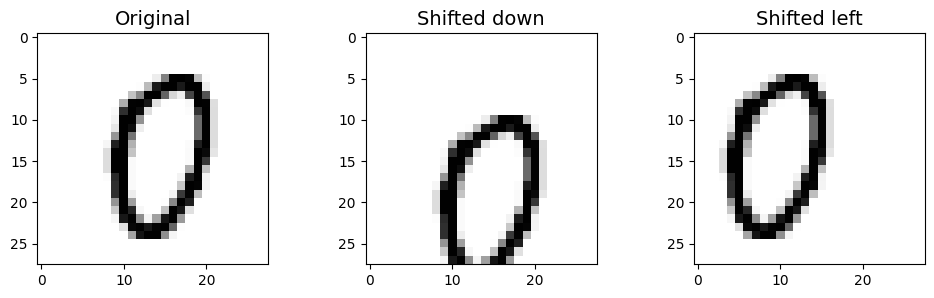

In [37]:
plt.figure(figsize=(12,3))

plt.subplot(131)
plt.title("Original", fontsize=14)
plt.imshow(image.reshape(28, 28), interpolation="nearest", cmap="Greys")

plt.subplot(132)
plt.title("Shifted down", fontsize=14)
plt.imshow(shifted_image_down.reshape(28, 28), interpolation="nearest", cmap="Greys")

plt.subplot(133)
plt.title("Shifted left", fontsize=14)
plt.imshow(shifted_image_left.reshape(28, 28), interpolation="nearest", cmap="Greys")

plt.show()

- 위에서 만든 함수는 보통 데이터 증강(data augmentation)에 사용

< 데이터 증강 >
- 기존 데이터를 변형해서 새로운 학습 데이터를 만드는 방법
- 머신러닝의 가장 큰 문제 = 데이터 부족
  - 과적합이 쉬움 (즉, 훈련 데이터만 잘 맞추고 새로운 데이터는 못 맞춤)
- 데이터 증강하면, 데이터의 의미는 유지하면서 형태만 바꾸고 수를 늘리는 것이기에 모델 일반화 성능이 증가함
- 즉, 같은 클래스의 다양한 형태를 보여줌
  - 예
    - 훈련 데이터가 숫자 5이고 이가 정중앙에 위치해있다면 '숫자는 항상 중앙에 있다'고 학습할 수 있음
    - 그러나 실제 데이터는 어디에든 있을 수 있기에 데이터 증강을 하면 모델이 위치 변화에 강해지기에 test accuracy가 상승함
- 데이터 증강 또한 regularization의 한 방법임


In [38]:
X_train_augmented = []
for image in X_train:
    X_train_augmented.append(image)
# = X_train_augmented = [image for image in X_train]
# X_train의 모든 이미지를 복사해서 새로운 리스트를 만듦

y_train_augmented = [label for label in y_train]

for dx, dy in ((1, 0), (-1, 0), (0, 1), (0, -1)):   # 네 방향으로 이동
    for image, label in zip(X_train, y_train):
      # zip()은 같은 위치의 요소들을 짝으로 묶어주는 역할
        X_train_augmented.append(shift_image(image, dx, dy))
        y_train_augmented.append(label)

X_train_augmented = np.array(X_train_augmented)
y_train_augmented = np.array(y_train_augmented)

In [39]:
shuffle_idx = np.random.permutation(len(X_train_augmented))
# 이미지와 라벨을 같은 순서로 섞음
X_train_augmented = X_train_augmented[shuffle_idx]
y_train_augmented = y_train_augmented[shuffle_idx]

####  **STEP 3. 위에서 확장한 데이터셋을 이용하여, 1번 문제에서 찾은 최적 모델을 훈련시키고, 테스트 세트에서 정확도를 측정해보세요**

In [40]:
knn_clf = KNeighborsClassifier(**grid_search.best_params_)

In [41]:
knn_clf.fit(X_train_augmented, y_train_augmented)

KNeighborsClassifier(n_neighbors=4, weights='distance')

In [42]:
y_pred = knn_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.9763